In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from collections import defaultdict
import os

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [19]:
transform_train = transforms.Compose([
    transforms.Resize(299),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.Resize(299),
    transforms.ToTensor()
])

In [20]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
model = models.inception_v3(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

In [22]:
model.aux_logits = False

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [24]:
epochs = 3

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss/len(train_loader))

Epoch: 1 Loss: 0.3326243746975676
Epoch: 2 Loss: 0.1466385224147063
Epoch: 3 Loss: 0.10030243170098477


In [25]:
def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [26]:
fp32_accuracy = evaluate(model)

print("FP32 Accuracy:", fp32_accuracy)

FP32 Accuracy: 95.62


In [27]:
torch.save(model.state_dict(), "inception_fp32.pth")

size = os.path.getsize("inception_fp32.pth")/(1024*1024)

print("FP32 Model Size:", size, "MB")

FP32 Model Size: 96.20776081085205 MB


In [28]:
activation_scores = defaultdict(list)

def get_activation(name):

    def hook(model, input, output):

        act = output.detach().cpu()

        score = torch.mean(torch.abs(act), dim=[0,2,3])

        activation_scores[name].append(score)

    return hook

In [29]:
hooks = []

for name, layer in model.named_modules():

    if isinstance(layer, nn.Conv2d):

        hooks.append(layer.register_forward_hook(get_activation(name)))

In [30]:
model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        model(images)

In [31]:
for h in hooks:
    h.remove()

In [32]:
attention_scores = {}

for layer in activation_scores:

    scores = torch.stack(activation_scores[layer])

    attention_scores[layer] = torch.mean(scores, dim=0)

In [33]:
def quantize_tensor(tensor, bits):

    qmin = 0
    qmax = 2**bits - 1

    min_val = tensor.min()
    max_val = tensor.max()

    scale = (max_val - min_val) / (qmax - qmin + 1e-8)

    q_tensor = torch.round((tensor - min_val) / scale)

    q_tensor = torch.clamp(q_tensor, qmin, qmax)

    dequant = q_tensor * scale + min_val

    return dequant

In [34]:
for name, layer in model.named_modules():

    if isinstance(layer, nn.Conv2d):

        # Skip layers without activation scores
        if name not in attention_scores:
            continue

        weights = layer.weight.data
        scores = attention_scores[name]

        mean = torch.mean(scores)
        std = torch.std(scores)

        for idx, score in enumerate(scores):

            if score > mean + std:
                bits = 8

            elif score >= mean:
                bits = 7

            else:
                bits = 6

            weights[idx] = quantize_tensor(weights[idx], bits)

In [35]:
daabq_accuracy = evaluate(model)

print("DAABQ Accuracy:", daabq_accuracy)

DAABQ Accuracy: 95.32


In [36]:
quantized_state_dict = {}

for name, param in model.state_dict().items():

    if "weight" in name:

        min_val = param.min()
        max_val = param.max()

        scale = (max_val - min_val) / 255

        q = torch.round((param - min_val) / scale).to(torch.uint8)

        quantized_state_dict[name] = q
        quantized_state_dict[name+"_scale"] = scale
        quantized_state_dict[name+"_min"] = min_val

    else:
        quantized_state_dict[name] = param

In [37]:
torch.save(quantized_state_dict, "inception_daabq.pth")

size = os.path.getsize("inception_daabq.pth")/(1024*1024)

print("DAABQ Model Size:", size, "MB")

DAABQ Model Size: 24.46029567718506 MB


In [38]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[943   1  24   3   2   0   1   2  23   1]
 [  1 973   0   0   0   0   0   0  13  13]
 [  8   0 967   5   6   7   6   1   0   0]
 [  1   1  17 919   6  27  13   4  11   1]
 [  3   0  22   9 948   4   4   9   1   0]
 [  0   0  10  56   6 917   1   8   1   1]
 [  3   0  23  11   2   4 954   1   1   1]
 [  3   0   6   3  19   4   0 965   0   0]
 [  6   1   2   0   0   0   1   0 986   4]
 [  4  17   1   1   0   0   1   0  16 960]]


In [39]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [40]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# CIFAR-10 class names
classes = ['Airplane','Automobile','Bird','Cat','Deer',
           'Dog','Frog','Horse','Ship','Truck']


def plot_confusion_matrix(model, dataloader, device, title):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

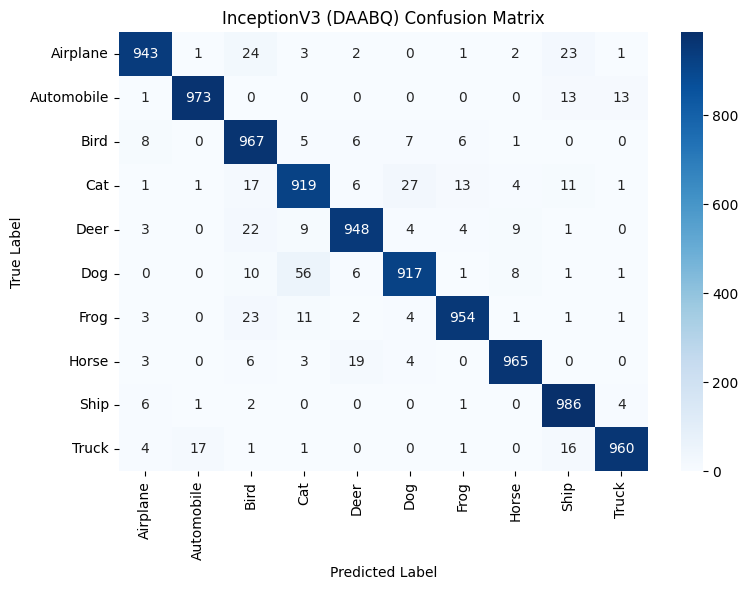

In [45]:
plot_confusion_matrix(model, test_loader, device,
                      "InceptionV3 (DAABQ) Confusion Matrix")